In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
num_classes = len(np.unique(y_train))  # = 10 for CIFAR-10

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print('Train:', x_train.shape, 'Test:', x_test.shape)
print('Train:', y_train.shape, 'Test:', y_test.shape)

Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)
Train: (50000, 1) Test: (10000, 1)


In [3]:

import os
import json
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

classifier_path = "models/classifier.weights.h5"
classifier_history_path = "models/classifier_history.json"

# Define num_classes based on the output of your classifier
num_classes = 10  # Set this to the number of classes in your problem

# Build classifier model
classifier = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=x_train.shape[1:]),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
classifier.summary()


d:\Project_Ai\Deep-Learning-Projects-main\Deep-Learning-Projects-main\Autoencoder - Deep CNN - Copy (2)\my_ml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:

# Set up callbacks
checkpoint = ModelCheckpoint(classifier_path, monitor='val_accuracy', save_best_only=True, save_weights_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Initialize loaded_history to None
loaded_history = None

# Load the history if it exists
if os.path.exists(classifier_history_path):
    with open(classifier_history_path, "r") as f:
        loaded_history = json.load(f)

# Train or load the model
if not os.path.exists(classifier_path):
    history = classifier.fit(
        x_train, y_train_cat,
        epochs=17,
        batch_size=128,
        validation_split=0.1,
        callbacks=[checkpoint, early_stop]
    )
    # Save training history
    with open(classifier_history_path, "w") as f:
        json.dump(history.history, f)
else:
    classifier.load_weights(classifier_path)
    print(f"Loaded weights from {classifier_path}")
    if loaded_history is None:
        print("No classifier history found. No plots will be generated.")
    else:
        print("Loaded classifier history.")


Loaded weights from models/classifier.weights.h5
Loaded classifier history.


d:\Project_Ai\Deep-Learning-Projects-main\Deep-Learning-Projects-main\Autoencoder - Deep CNN - Copy (2)\my_ml_env\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


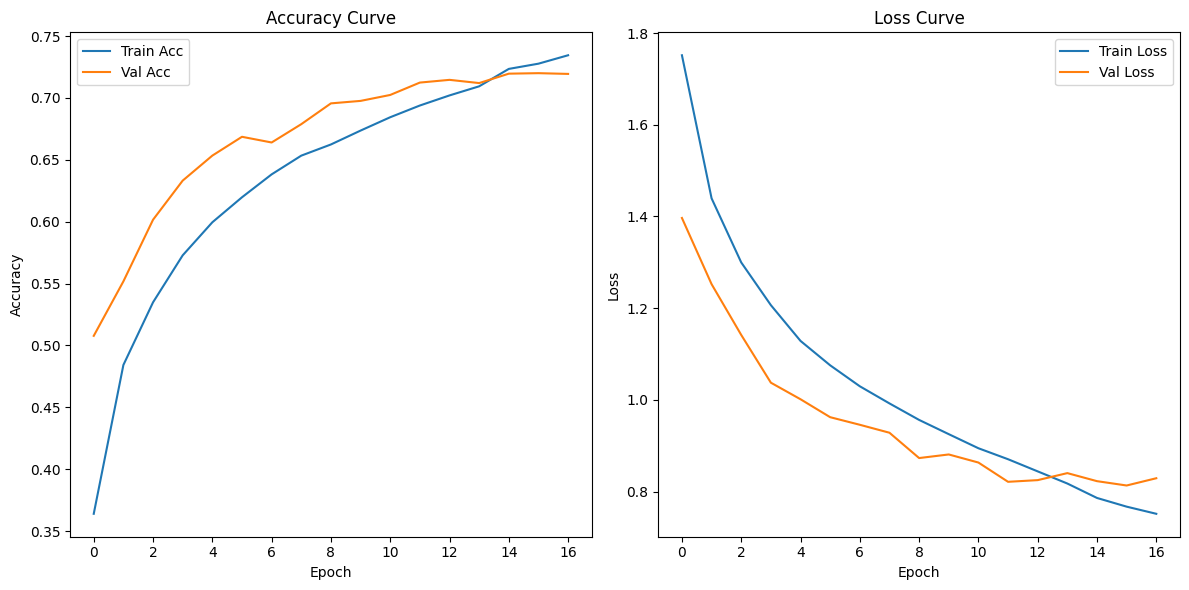

In [5]:
# Plot training and validation accuracy and loss
if loaded_history is not None:
    plot_data = loaded_history  # History loaded from file

    plt.figure(figsize=(12, 6))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(plot_data['accuracy'], label='Train Acc')
    plt.plot(plot_data['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(plot_data['loss'], label='Train Loss')
    plt.plot(plot_data['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()
else:
    print("No history available for plotting.")


In [6]:
test_loss, test_acc = classifier.evaluate(x_test, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")

predictions = classifier.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7022 - loss: 0.8497
Test Accuracy: 0.7056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


In [7]:
# 1) Reconstruct the autoencoder architecture
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(32, 32, 3))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(8, (3,3), activation='relu', padding='same', name='latent_space')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(8, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# 2) Load the trained weights
autoencoder.load_weights('models/autoencoder.weights.h5')


d:\Project_Ai\Deep-Learning-Projects-main\Deep-Learning-Projects-main\Autoencoder - Deep CNN - Copy (2)\my_ml_env\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


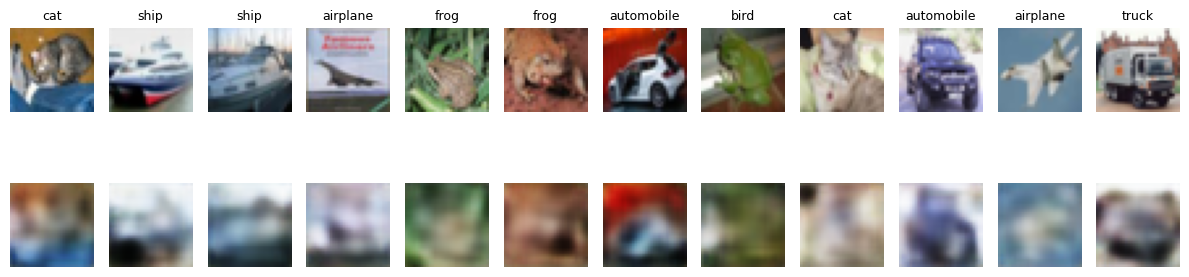

In [8]:
import matplotlib.pyplot as plt

import numpy as np

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# # Reconstruct images with autoencoder
# decoded_imgs = autoencoder.predict(x_test[:10])

# # Plot original images with predicted labels and reconstructed images
# plt.figure(figsize=(10, 3.8))
# for i in range(10):
#     # Original images with predicted labels
#     ax = plt.subplot(2, 10, i + 1)
#     plt.imshow(x_test[i])
#     plt.title(f"{class_names[predicted_labels[i]]}", fontsize=11)
#     plt.axis('off')

#     # Reconstructed images
#     ax = plt.subplot(2, 10, i + 11)
#     plt.imshow(decoded_imgs[i])
#     plt.axis('off')

# plt.tight_layout()
# plt.show()



# Predict class probabilities (assuming classifier and x_test are defined)
predictions = classifier.predict(x_test[:12])
predicted_labels = np.argmax(predictions, axis=1)

# Reconstruct images with autoencoder (assuming autoencoder is defined)
decoded_imgs = autoencoder.predict(x_test[:12])

# Plot original images with predicted labels and reconstructed images
plt.figure(figsize=(12, 4))
for i in range(12):
    # Original image
    ax = plt.subplot(2, 12, i + 1)
    plt.imshow(x_test[i])
    plt.title(f"{class_names[predicted_labels[i]]}", fontsize=9)
    plt.axis('off')

    # Reconstructed image
    ax = plt.subplot(2, 12, i + 13)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


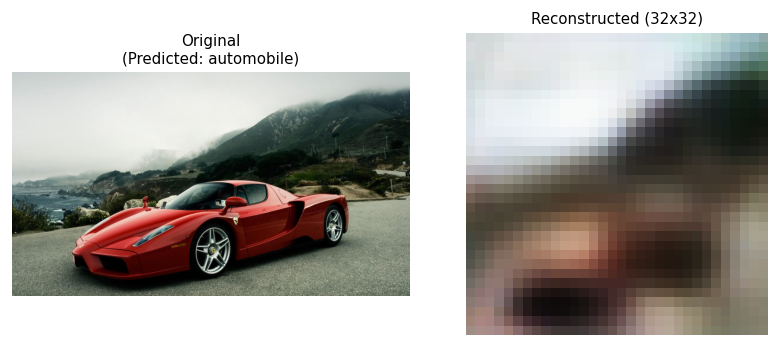

In [10]:
from tensorflow.keras.preprocessing import image



# === Load your image ===
img_path = r"C:\Users\mhmd2\Downloads\Ai_pic\car.jpg"  # Change if needed



# Original full-res (just for display)
original_img = image.load_img(img_path)
original_array = image.img_to_array(original_img).astype('float32') / 255.0

# Resize for model input
resized_img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(resized_img).astype('float32') / 255.0
img_array = np.expand_dims(img_array, axis=0)

# === Predict with Classifier ===
prediction = classifier.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_name = class_names[predicted_index]

# === Reconstruct with Autoencoder ===
reconstructed = autoencoder.predict(img_array)

# === Plot results ===
plt.figure(figsize=(7, 3), dpi=120)

# Original full-size image
plt.subplot(1, 2, 1)
plt.imshow(original_array)
plt.title(f"Original\n(Predicted: {predicted_name})", fontsize=9)
plt.axis('off')

# Reconstructed 32x32 image
plt.subplot(1, 2, 2)
plt.imshow(reconstructed[0])
plt.title("Reconstructed (32x32)", fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


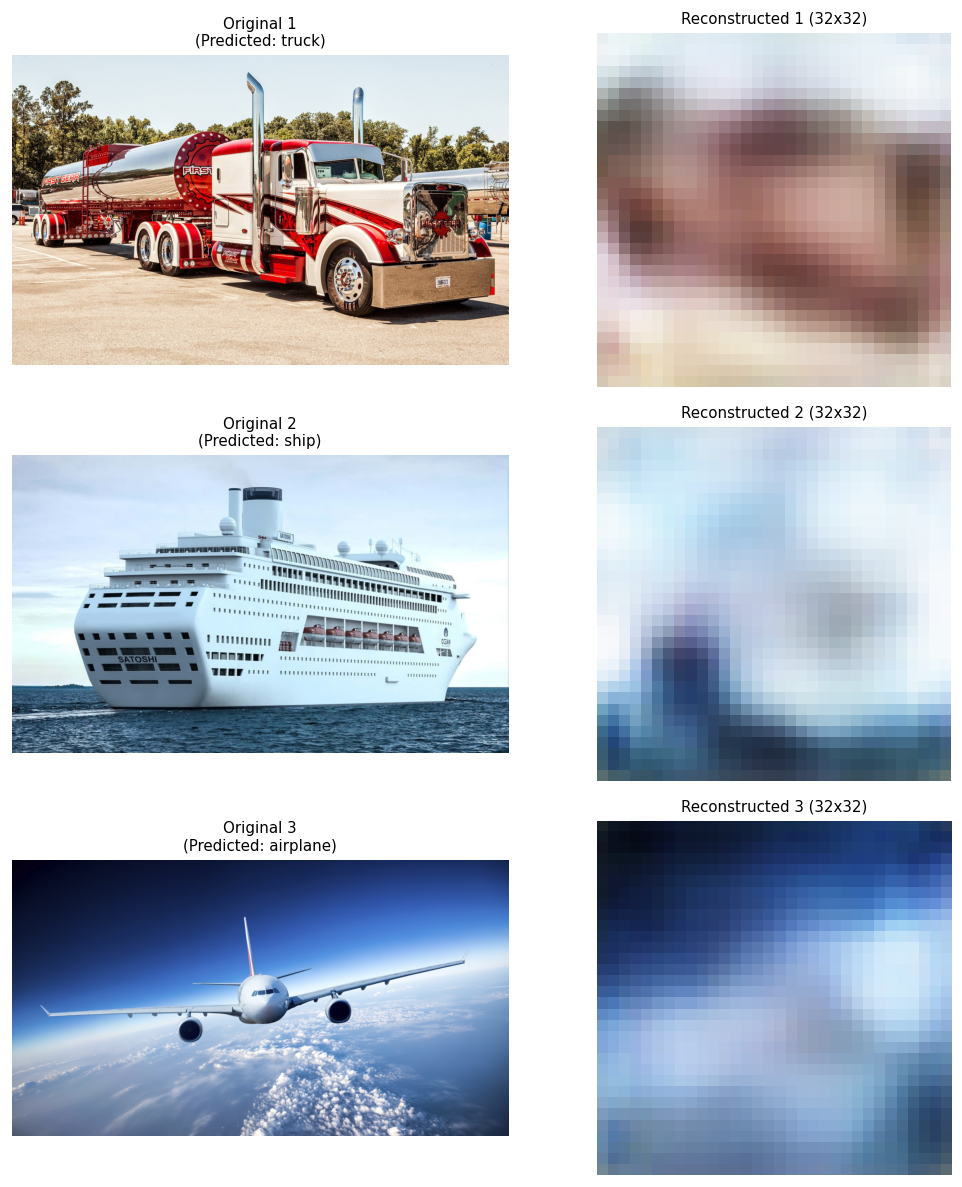

In [11]:
# Paths for your images
img_paths = [
    r"C:\Users\mhmd2\Downloads\Ai_pic\t2.jpeg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\ship.jpg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\airplane.jpg",
    # r"C:\Users\mhmd2\Downloads\Ai_pic\cat.png"
    # r"C:\Users\mhmd2\Downloads\Ai_pic\cat1.jpg"
    #  r"C:\Users\mhmd2\Downloads\Ai_pic\t3.jpeg"
    # r"C:\Users\mhmd2\Downloads\Ai_pic\b2.jpeg"
    
]

# Create subplots for the images
plt.figure(figsize=(13, 10), dpi=120)

for i, img_path in enumerate(img_paths, start=1):
    # Load original full-res image (just for display)
    original_img = image.load_img(img_path)
    original_array = image.img_to_array(original_img).astype('float32') / 255.0  # Normalize the image

    # Resize for model input
    resized_img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(resized_img).astype('float32') / 255.0  # Normalize the image
    img_array = np.expand_dims(img_array, axis=0)

    # Predict with Classifier (assuming classifier is defined)
    prediction = classifier.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_name = class_names[predicted_index]

    # Reconstruct with Autoencoder (assuming autoencoder is defined)
    reconstructed = autoencoder.predict(img_array)

    # Plot results for the original and reconstructed image
    # plt.subplot(3, 4, i * 2 - 1)

    plt.subplot(3, 3, i*3-1)  # Left side: Original Image
    plt.imshow(original_array)
    plt.title(f"Original {i}\n(Predicted: {predicted_name})", fontsize=9)
    plt.axis('off')

    # plt.subplot(3, 4, i * 2)
    plt.subplot(3, 3, i*3)  # Right side: Reconstructed Image
    plt.imshow(reconstructed[0])  # Reconstructed image from the autoencoder
    plt.title(f"Reconstructed {i} (32x32)", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


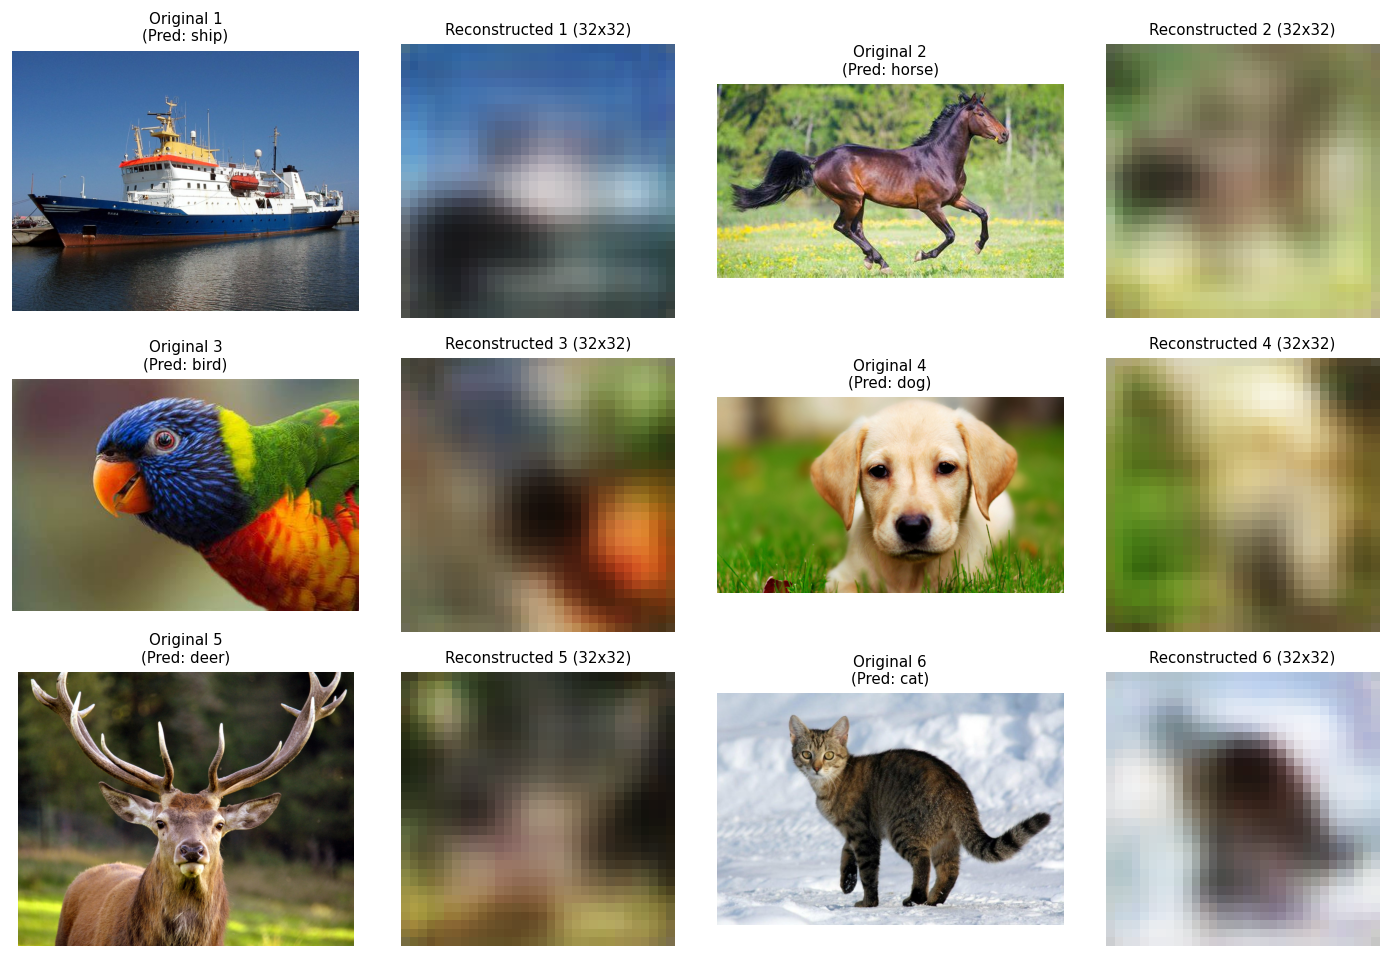

In [12]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

img_paths = [
    r"C:\Users\mhmd2\Downloads\Ai_pic\ship2.jpeg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\h.jpeg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\b.jpeg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\dog2.jpeg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\DEER.jpeg",
    r"C:\Users\mhmd2\Downloads\Ai_pic\cat1.jpg"
]

# Create subplots (3 rows, 4 columns for 6 original + 6 reconstructed)
plt.figure(figsize=(12, 8), dpi=120)

for i, img_path in enumerate(img_paths, start=1):
    # Load original full-res image (for display)
    original_img = image.load_img(img_path)
    original_array = image.img_to_array(original_img).astype('float32') / 255.0  # Normalize

    # Resize for model input
    resized_img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(resized_img).astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict with Classifier (assuming classifier is defined)
    prediction = classifier.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_name = class_names[predicted_index]

    # Reconstruct with Autoencoder (assuming autoencoder is defined)
    reconstructed = autoencoder.predict(img_array)

    # Subplot index (original on left, reconstructed on right)
    plt.subplot(3, 4, i * 2 - 1)
    plt.imshow(original_array)
    plt.title(f"Original {i}\n(Pred: {predicted_name})", fontsize=9)
    plt.axis('off')

    plt.subplot(3, 4, i * 2)
    plt.imshow(reconstructed[0])
    plt.title(f"Reconstructed {i} (32x32)", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


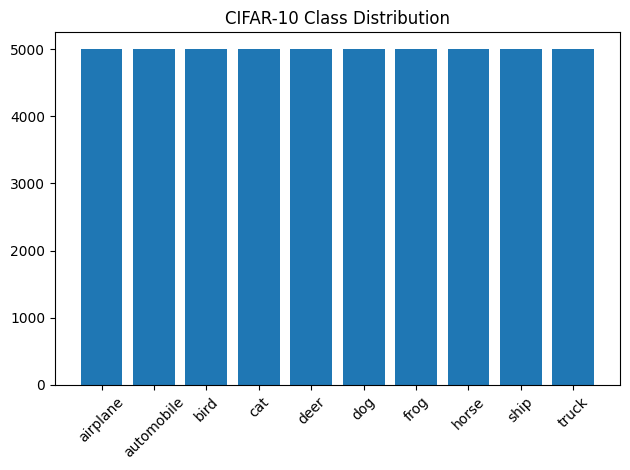

In [13]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, y_train), _ = cifar10.load_data()
counts = np.bincount(y_train.flatten())
plt.bar(range(10), counts)
plt.xticks(range(10), class_names, rotation=45)
plt.title("CIFAR-10 Class Distribution")
plt.tight_layout()
plt.savefig("cifar_distribution.png", dpi=300)
